# UTK Problem

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
img = cv2.imread('Gonzalez_images/UTK.tif', 0)

[ WARN:0@133.684] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


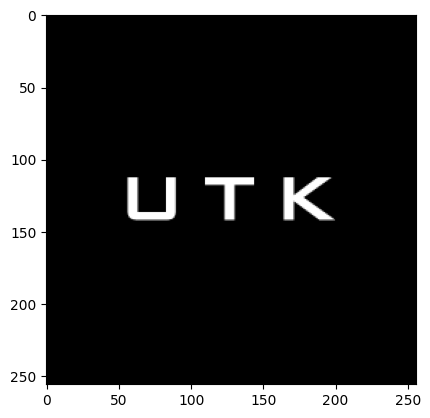

In [5]:
plt.imshow(img, cmap='gray')

In [21]:
kernel = cv2.imread('Gonzalez_images/T.tif', 0)

## Problem: Opening with the same kernel

In [30]:
opening_img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

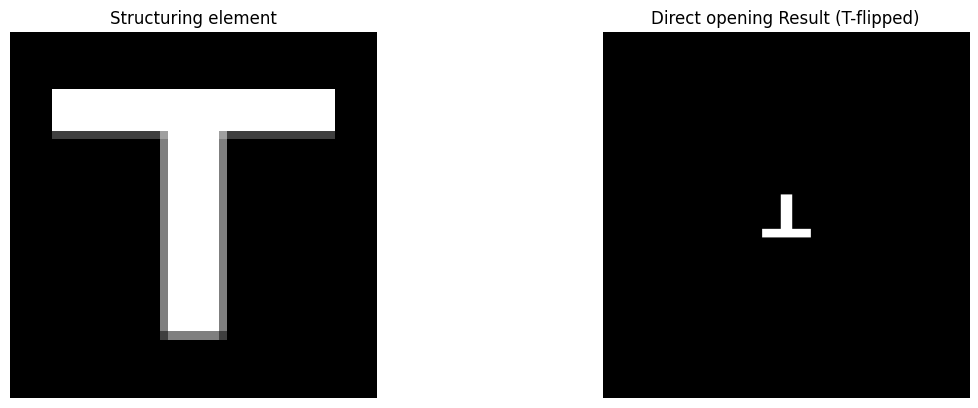

In [23]:
images = [kernel, opening_img]
captions = ["Structuring element", 'Direct opening Result (T-flipped)']

fig = plt.figure(figsize=(12, 8))

for i in range(2):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.imshow(images[i], cmap='gray')
    ax.set_title(captions[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Solving the problem

### Erosion with kernel

In [17]:
eroded_img = cv2.erode(img, kernel, iterations=1)

### Flipping the kernel

In [14]:
kernel_flipped = cv2.flip(kernel, 0)

### Dilation with flipped kernel

In [24]:
dilated_img = cv2.dilate(eroded_img, kernel_flipped, iterations=1)

### Results

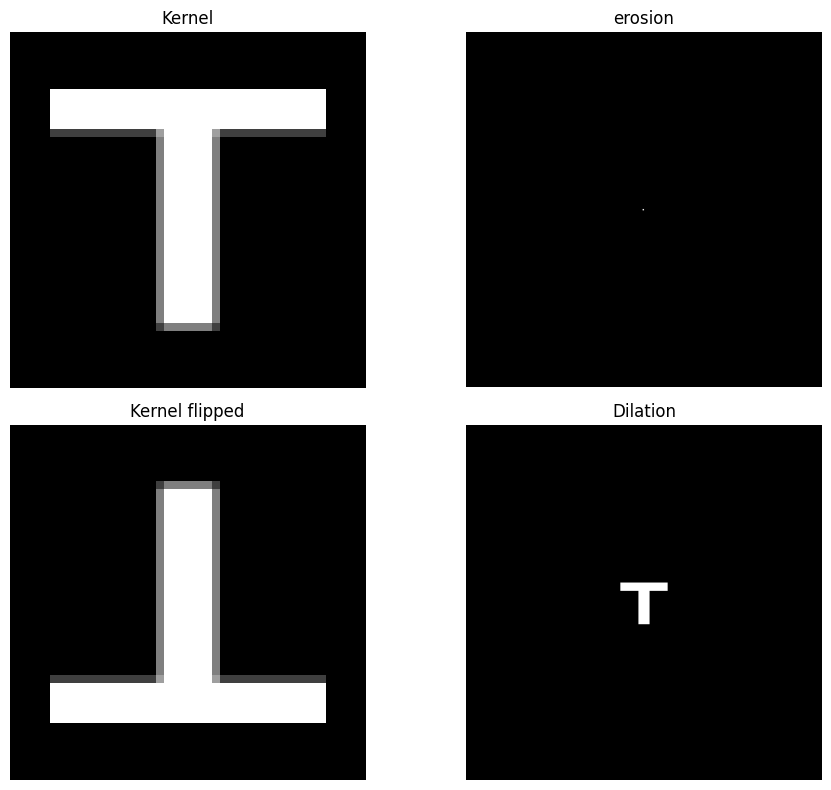

In [29]:
images = [kernel, eroded_img, kernel_flipped, dilated_img]
captions = ["Kernel", 'erosion', 'Kernel flipped', 'Dilation']

fig = plt.figure(figsize=(10, 8))

for i in range(4):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.imshow(images[i], cmap='gray')
    ax.set_title(captions[i])
    ax.axis('off')
plt.tight_layout()
plt.show()